# PROG8431 - Group Assignment 1
**Team Members:**
1. Sukhchain Singh (ID: 9111541)
2. Preethi (ID: 9125985)
3. Arya (ID: 45678912)

## What is Our Project About?

Imagine you run a city bike-sharing program with thousands of bicycles parked at stations around the city. On a warm, sunny day, hundreds of people want to rent bikes. On a cold, rainy day, almost nobody rides. 

If you put out too few bikes on a nice day, customers get disappointed. If you put out too many on a rainy day, bikes sit unused.

In this project, we analyze 731 real days of bike rentals alongside daily weather metrics (like temperature, humidity, and season). Our goal is to uncover patterns so the company knows exactly how many bikes to prepare tomorrow!

## Data source and research question

We use the daily file from the UCI Bike Sharing Dataset. Each row represents one day in the Capital Bikeshare system during 2011–2012 and includes rental counts, calendar information, and weather measurements. The dataset has 731 daily records and no missing values according to UCI.

**Research question:** How do daily temperature and season relate to total bike rentals? This question helps operators understand when demand tends to be higher, although this descriptive analysis does not establish cause and effect.

**Source:** Fanaee-T, H. (2013). *Bike Sharing* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894. Dataset page: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset.

The project currently loads a downloaded local copy from data/day.csv; the source download step is not automated in this notebook.

## Questions Considered When Choosing the Data

- **Does the dataset contain enough observations?**  
  Yes. The dataset contains 731 daily observations covering 2011–2012.

- **Does it contain numerical variables suitable for statistical analysis?**  
  Yes. It includes temperature, humidity, and total rental counts.

- **Does the data relate to our research question?**  
  Yes. The dataset contains temperature, season, and total rental demand, which are the variables required for our analysis.

- **Is the dataset available in a usable format?**  
  Yes. The Bike Sharing Dataset provides the daily observations in CSV format.

# PROG8431 - Group Assignment 1
**Team Members:**
1. Sukhchain Singh (ID: 9111541)
2. Preethi (ID: 9125985)
3. Arya (ID: 45678912)

**Research Question:** How are temperature and season associated with daily Capital Bikeshare rental demand?


## Use Case and Context

Bike-sharing operators need to understand how rental demand changes under different weather conditions and seasons. Knowing these patterns can help them make better decisions about **bike availability, maintenance, and daily operations**.

In this project, we analyze historical **Capital Bikeshare** data to study how **temperature and season are associated with daily bike rental demand**. The dataset contains **731 daily records from 2011–2012**, including information such as daily rental counts, temperature, humidity, and season.

By using descriptive statistics and visualizations, we can identify historical patterns, such as whether rental demand tends to be higher or lower at different temperatures and during different seasons. This analysis focuses on **understanding past relationships rather than predicting future demand or proving that weather directly causes changes in rentals**.

## Data Source

**Source:** Fanaee-T, H. (2013). *Bike Sharing* [Dataset]. UCI Machine Learning Repository.  
https://doi.org/10.24432/C5W894

The dataset contains **731 daily bike rental records from 2011 to 2012**. Each row represents one day.

For our analysis, we mainly use:
- `cnt` – total number of daily rentals
- `temp` – normalized temperature
- `hum` – normalized humidity
- `season` – season of the year

The `day.csv` file is stored in the project's `data` folder and loaded using pandas.

## Questions Considered When Choosing the Data

- **Does the dataset contain enough observations?**  
  Yes. The dataset contains 731 daily observations covering 2011–2012.

- **Does it contain numerical variables suitable for statistical analysis?**  
  Yes. It includes temperature, humidity, and total rental counts.

- **Does the data relate to our research question?**  
  Yes. The dataset contains temperature, season, and total rental demand, which are the variables required for our analysis.

- **Is the dataset available in a usable format?**  
  Yes. The Bike Sharing Dataset provides the daily observations in CSV format.

In [ ]:

# Libraries used for data analysis and visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib_venn import venn2

## Data Checks and Cleansing

Before analyzing the data, we check that the dataset is accurate and ready to use.

We:
- Check for missing values and duplicate dates.
- Verify that the season codes are valid.
- Verify that total rentals equal casual rentals + registered rentals.
- Convert temperature to Celsius.
- Convert humidity to percentage.
- Convert season codes into readable season names such as Winter, Spring, Summer, and Fall.
- Remove duplicate rows if any are found.

In [ ]:
# Load real-world daily bike rental data
df = pd.read_csv('../data/day.csv')

print("Dataset successfully loaded.")


# ============================================================
# Data Validation
# ============================================================

# Step 1: Check that all required columns are available
required_columns = {
    'dteday',
    'season',
    'temp',
    'hum',
    'cnt',
    'casual',
    'registered'
}

missing_columns = required_columns - set(df.columns)

# Stop only if an important column itself is missing
if missing_columns:
    raise ValueError(f"Missing columns: {sorted(missing_columns)}")


# Step 2: Convert the date column to datetime format
df['dteday'] = pd.to_datetime(df['dteday'], errors='raise')


# Step 3: Check the dataset for missing values
# We only report them here because the UCI dataset is expected
# to contain no missing values.
missing_values = df.isna().sum().sum()

print(f"Number of rows: {len(df)}")
print(f"Missing values: {missing_values}")


# Step 4: Check for duplicate dates
duplicate_dates = df['dteday'].duplicated().sum()

print(f"Duplicate dates: {duplicate_dates}")


# Step 5: Validate season codes
# UCI defines: 1 = Winter, 2 = Spring, 3 = Summer, 4 = Fall
if not df['season'].isin([1, 2, 3, 4]).all():
    raise ValueError("Unexpected season code found.")


# Step 6: Verify that total rentals are correct
# Total rentals should equal casual rentals + registered rentals
if not (df['casual'] + df['registered'] == df['cnt']).all():
    raise ValueError("Rental totals do not match casual + registered rentals.")


# ============================================================
# Data Cleansing and Transformation
# ============================================================

# Step 7: Convert normalized temperature to Celsius
df['Temperature_C'] = (df['temp'] * 41).round(1)


# Step 8: Convert normalized humidity to percentage
df['Humidity_Pct'] = (df['hum'] * 100).round(1)


# Step 9: Rename important columns for readability
df.rename(columns={
    'cnt': 'Total_Rentals',
    'workingday': 'Working_Day',
    'season': 'Season_Code'
}, inplace=True)


# Step 10: Convert season codes to meaningful season names
season_map = {
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Fall'
}

df['Season'] = df['Season_Code'].map(season_map)


# Step 11: Remove duplicate rows if any exist
duplicates_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"Duplicate rows removed: {duplicates_before}")


# ============================================================
# Display Cleaned Data
# ============================================================

print("\nData successfully validated and cleansed:")

display(
    df[
        [
            'dteday',
            'Season',
            'Temperature_C',
            'Humidity_Pct',
            'Working_Day',
            'Total_Rentals'
        ]
    ].head(10)
)

Dataset successfully loaded.
Number of rows: 731
Missing values: 0
Duplicate dates: 0
Duplicate rows removed: 0

Data successfully validated and cleansed:


,dteday,Season,Temperature_C,Humidity_Pct,Working_Day,Total_Rentals
0,2011-01-01,Winter,14.1,80.6,0,985
1,2011-01-02,Winter,14.9,69.6,0,801
2,2011-01-03,Winter,8.1,43.7,1,1349
3,2011-01-04,Winter,8.2,59.0,1,1562
4,2011-01-05,Winter,9.3,43.7,1,1600
5,2011-01-06,Winter,8.4,51.8,1,1606
6,2011-01-07,Winter,8.1,49.9,1,1510
7,2011-01-08,Winter,6.8,53.6,0,959
8,2011-01-09,Winter,5.7,43.4,0,822
9,2011-01-10,Winter,6.2,48.3,1,1321


## 50-word use case summary

Capital Bikeshare managers need to understand when daily demand rises or falls. We analyze 731 days of rental totals, temperature, and seasons from 2011 to 2012. Descriptive statistics and visualizations show historical associations that may guide fleet planning and maintenance scheduling. They do not provide station-level forecasts or establish causation.


## Numerical Exploration

In this section, we calculate descriptive statistics to better understand the bike rental data.

We calculate:
- **Mean, median, and mode** to understand the typical values.
- **Variance and standard deviation** to understand how much the values vary.
- **Quartiles (Q1–Q4)** to understand how the values are distributed.

Our main focus is **daily bike rentals**, with temperature also analyzed because it is part of our research question.

In [ ]:
class BikeDemandAnalyzer:
    """Summarize daily rental demand and the variables in the research question."""

    # ============================================================
    # Step 1: Initialize the Analyzer
    # ============================================================

    def __init__(self, data):
        # Store the cleaned dataset so all methods in this class can use it
        self.data = data


    # ============================================================
    # Step 2: Calculate Statistics for a Numeric Column
    # ============================================================

    def statistics(self, column):
        """Calculate central tendency, spread, and quartiles for a numeric column."""

        # Remove missing values from the selected column before calculation
        values = self.data[column].dropna()

        # Find all modes because a dataset may have more than one mode
        modes = values.mode().tolist()

        # Calculate and return the required descriptive statistics
        return pd.Series({
            "Count": len(values),

            # Measures of central tendency
            "Mean": values.mean(),
            "Median": values.median(),
            "Mode(s)": ", ".join(f"{x:g}" for x in modes),

            # Measures of spread
            "Sample variance": values.var(ddof=1),
            "Sample standard deviation": values.std(ddof=1),

            # Quartiles
            "Q1 (25%)": values.quantile(.25),
            "Q2 (50%)": values.quantile(.50),
            "Q3 (75%)": values.quantile(.75),
            "Q4 (100%; maximum)": values.quantile(1)
        })


    # ============================================================
    # Step 3: Create Overall and Seasonal Numerical Summaries
    # ============================================================

    def numerical_summary(self):
        """Display overall numerical statistics and seasonal rental summaries."""

        # Select the main numerical variables used in the analysis
        columns = [
            "Total_Rentals",
            "Temperature_C",
            "Humidity_Pct"
        ]

        # Display overall descriptive statistics
        display(
            self.data[columns]
            .describe()
            .round(2)
        )

        # Compare rental demand across the four seasons
        display(
            self.data.groupby("Season")["Total_Rentals"]
            .agg(
                Days="count",
                Mean="mean",
                Median="median",
                Min="min",
                Max="max"
            )
            .reindex(["Winter", "Spring", "Summer", "Fall"])
            .round(2)
        )


# ============================================================
# Step 4: Create an Object of the BikeDemandAnalyzer Class
# ============================================================

analyzer = BikeDemandAnalyzer(df)


# ============================================================
# Step 5: Display Required Statistics
# ============================================================

# Calculate statistics for daily rentals and temperature
for variable in ["Total_Rentals", "Temperature_C"]:

    print(f"\n{variable} (rentals/day or °C)")

    display(
        analyzer.statistics(variable)
        .to_frame("Value")
    )


# ============================================================
# Step 6: Display Overall and Seasonal Summary
# ============================================================

print("\nNumerical summary and seasonal comparison")

analyzer.numerical_summary()


Total_Rentals (rentals/day or °C)


,Value
Count,731
Mean,4504.348837
Median,4548.0
Mode(s),"1096, 1162, 1685, 1977, 2077, 2424, 2425, 3068..."
Sample variance,3752788.208283
Sample standard deviation,1937.211452
Q1 (25%),3152.0
Q2 (50%),4548.0
Q3 (75%),5956.0
Q4 (100%; maximum),8714.0



Temperature_C (rentals/day or °C)


,Value
Count,731
Mean,20.31067
Median,20.4
Mode(s),26.6
Sample variance,56.33016
Sample standard deviation,7.505342
Q1 (25%),13.8
Q2 (50%),20.4
Q3 (75%),26.9
Q4 (100%; maximum),35.3



Numerical summary and seasonal comparison


,Total_Rentals,Temperature_C,Humidity_Pct
count,731.00,731.00,731.00
mean,4504.35,20.31,62.79
std,1937.21,7.51,14.24
min,22.00,2.40,0.00
25%,3152.00,13.80,52.00
50%,4548.00,20.40,62.70
75%,5956.00,26.90,73.00
max,8714.00,35.30,97.20


,Days,Mean,Median,Min,Max
Season,,,,,
Winter,181,2604.13,2209.0,431,7836
Spring,184,4992.33,4941.5,795,8362
Summer,188,5644.30,5353.5,1115,8714
Fall,178,4728.16,4634.5,22,8555


## Four Views of the Data

We use four visualizations to better understand the bike rental data:

- **Scatter Plot:** Shows the relationship between temperature and daily bike rentals.
- **Histogram:** Shows how daily rental totals are distributed.
- **Box Plot:** Compares daily bike rentals across the four seasons.
- **Venn Diagram:** Shows the overlap between high-demand days (more than 5,000 rentals) and warm days (above 20°C).

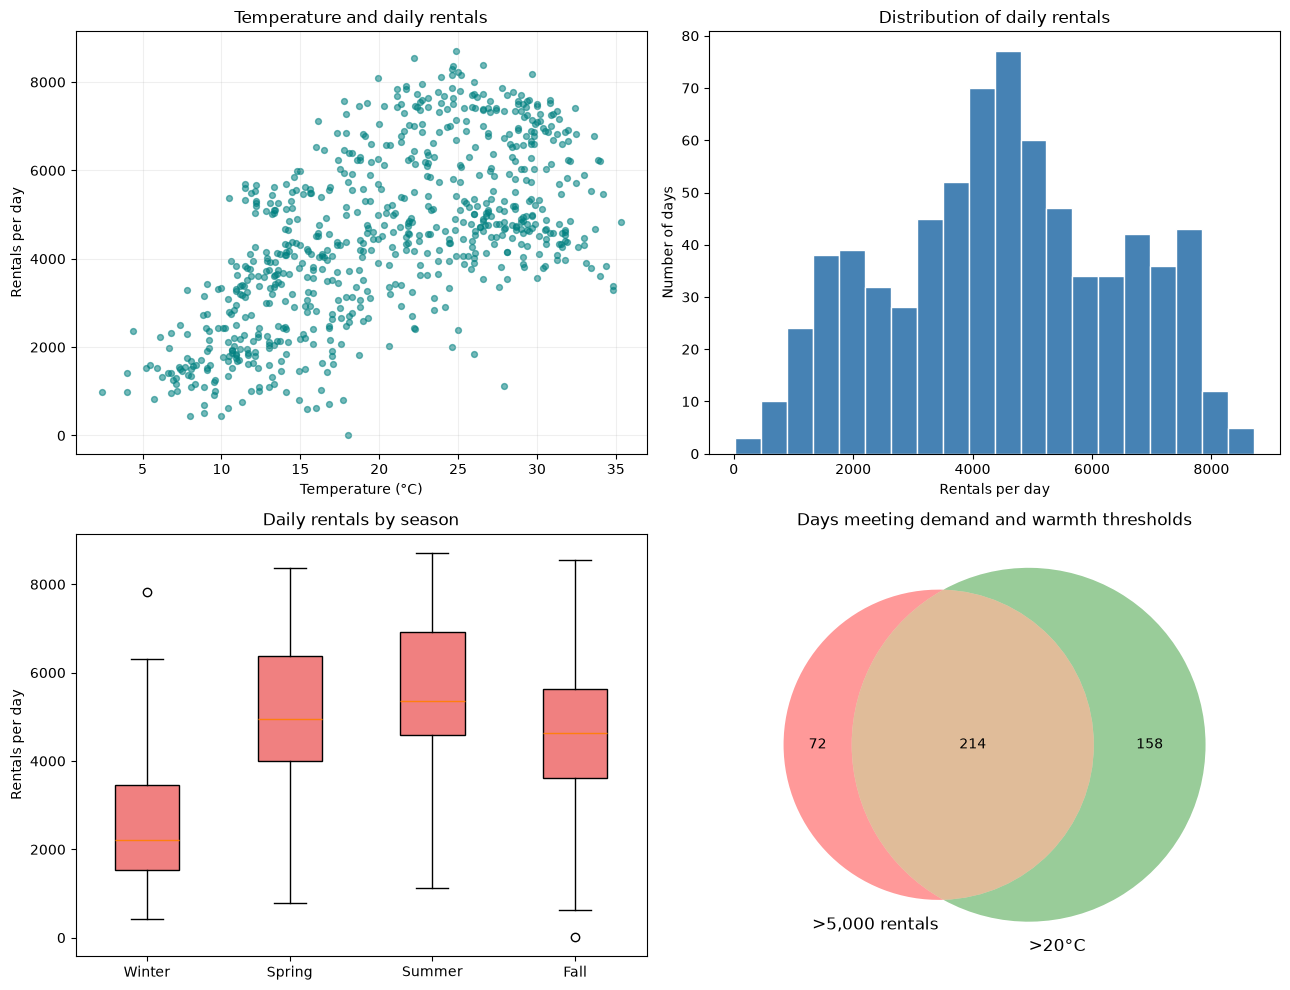

High-demand days: 286; warm days: 372; both: 214


In [ ]:
class BikeVisualizer:
    """Create four visualizations for the daily bike rental data."""

    # ============================================================
    # Step 1: Initialize the Visualizer
    # ============================================================

    def __init__(self, data):
        # Store the cleaned dataset so it can be used for plotting
        self.data = data


    # ============================================================
    # Step 2: Create All Four Required Visualizations
    # ============================================================

    def plot_all(self):
        """Create scatter plot, histogram, box plot, and Venn diagram."""

        # Create a 2 x 2 layout for the four visualizations
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))


        # ========================================================
        # Step 3: Scatter Plot - Temperature vs Daily Rentals
        # ========================================================

        # Compare temperature with the total number of daily rentals
        axes[0, 0].scatter(
            self.data.Temperature_C,
            self.data.Total_Rentals,
            alpha=0.55,
            s=18,
            color="teal"
        )

        # Add title and axis labels
        axes[0, 0].set(
            title="Temperature and daily rentals",
            xlabel="Temperature (°C)",
            ylabel="Rentals per day"
        )

        axes[0, 0].grid(alpha=0.2)


        # ========================================================
        # Step 4: Histogram - Distribution of Daily Rentals
        # ========================================================

        # Show how frequently different daily rental totals occur
        axes[0, 1].hist(
            self.data.Total_Rentals,
            bins=20,
            color="steelblue",
            edgecolor="white"
        )

        # Add title and axis labels
        axes[0, 1].set(
            title="Distribution of daily rentals",
            xlabel="Rentals per day",
            ylabel="Number of days"
        )


        # ========================================================
        # Step 5: Box Plot - Compare Rentals Across Seasons
        # ========================================================

        # Define the order of the seasons
        seasons = ["Winter", "Spring", "Summer", "Fall"]

        # Collect rental values separately for each season
        season_values = [
            self.data.loc[
                self.data.Season.eq(season),
                "Total_Rentals"
            ]
            for season in seasons
        ]

        # Create the seasonal box plot
        axes[1, 0].boxplot(
            season_values,
            patch_artist=True,
            boxprops={"facecolor": "lightcoral"}
        )

        # Add season names to the x-axis
        axes[1, 0].set_xticks(range(1, len(seasons) + 1))
        axes[1, 0].set_xticklabels(seasons)

        # Add title and axis label
        axes[1, 0].set(
            title="Daily rentals by season",
            ylabel="Rentals per day"
        )


        # ========================================================
        # Step 6: Venn Diagram - High Demand and Warm Days
        # ========================================================

        # Find days with more than 5,000 rentals
        high = set(
            self.data.index[
                self.data.Total_Rentals.gt(5000)
            ]
        )

        # Find days where temperature was above 20°C
        warm = set(
            self.data.index[
                self.data.Temperature_C.gt(20)
            ]
        )

        # Show the overlap between high-demand days and warm days
        venn2(
            [high, warm],
            set_labels=(">5,000 rentals", ">20°C"),
            ax=axes[1, 1]
        )

        axes[1, 1].set_title(
            "Days meeting demand and warmth thresholds"
        )


        # ========================================================
        # Step 7: Display the Visualizations
        # ========================================================

        # Adjust spacing so the plots do not overlap
        fig.tight_layout()

        # Display all four plots
        plt.show()


        # ========================================================
        # Step 8: Display Venn Diagram Counts
        # ========================================================

        # Print the number of high-demand days, warm days,
        # and days that meet both conditions
        print(
            f"High-demand days: {len(high)}; "
            f"warm days: {len(warm)}; "
            f"both: {len(high & warm)}"
        )


# ============================================================
# Step 9: Create the Visualizer Object and Display the Plots
# ============================================================

BikeVisualizer(df).plot_all()

## Presentation Guide

### 1. Introduction
Our project analyzes daily bike rental data to understand how temperature and season are related to the number of bike rentals.

### 2. Dataset and Data Cleaning
We use the UCI Bike Sharing Dataset, which contains 731 days of data from 2011 to 2012. Before analysis, we check for missing values, duplicates, valid season codes, and correct rental totals. We also convert temperature to Celsius and humidity to percentage.

### 3. Statistical Analysis
We calculate mean, median, mode, variance, standard deviation, and quartiles to understand the typical rental demand and how much the values vary.

### 4. Visualizations
We use four graphs:
- Scatter plot to compare temperature and rentals.
- Histogram to show the distribution of daily rentals.
- Box plot to compare rentals across seasons.
- Venn diagram to show the overlap between warm days and high-demand days.

### 5. Conclusion
The statistics and graphs help us understand historical patterns in bike rentals and how rental demand is associated with temperature and season.

## References

Fanaee-T, H. (2013). *Bike Sharing* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894

# PROG8431 - Group Assignment 1
**Team Members:**
1. Sukhchain Singh (ID: 9111541)
2. Preethi (ID: 9125985)
3. Arya (ID: 45678912)

**Research Question:** How are temperature and season associated with daily Capital Bikeshare rental demand?


## Use Case and Context

Bike-sharing operators need to understand how rental demand changes under different weather conditions and seasons. Knowing these patterns can help them make better decisions about **bike availability, maintenance, and daily operations**.

In this project, we analyze historical **Capital Bikeshare** data to study how **temperature and season are associated with daily bike rental demand**. The dataset contains **731 daily records from 2011–2012**, including information such as daily rental counts, temperature, humidity, and season.

By using descriptive statistics and visualizations, we can identify historical patterns, such as whether rental demand tends to be higher or lower at different temperatures and during different seasons. This analysis focuses on **understanding past relationships rather than predicting future demand or proving that weather directly causes changes in rentals**.

## Data Source

**Source:** Fanaee-T, H. (2013). *Bike Sharing* [Dataset]. UCI Machine Learning Repository.  
https://doi.org/10.24432/C5W894

The dataset contains **731 daily bike rental records from 2011 to 2012**. Each row represents one day.

For our analysis, we mainly use:
- `cnt` – total number of daily rentals
- `temp` – normalized temperature
- `hum` – normalized humidity
- `season` – season of the year

The `day.csv` file is stored in the project's `data` folder and loaded using pandas.

## Questions Considered When Choosing the Data

- **Does the dataset contain enough observations?**  
  Yes. The dataset contains 731 daily observations covering 2011–2012.

- **Does it contain numerical variables suitable for statistical analysis?**  
  Yes. It includes temperature, humidity, and total rental counts.

- **Does the data relate to our research question?**  
  Yes. The dataset contains temperature, season, and total rental demand, which are the variables required for our analysis.

- **Is the dataset available in a usable format?**  
  Yes. The Bike Sharing Dataset provides the daily observations in CSV format.

In [ ]:

# Libraries used for data analysis and visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib_venn import venn2

## Data Checks and Cleansing

Before analyzing the data, we check that the dataset is accurate and ready to use.

We:
- Check for missing values and duplicate dates.
- Verify that the season codes are valid.
- Verify that total rentals equal casual rentals + registered rentals.
- Convert temperature to Celsius.
- Convert humidity to percentage.
- Convert season codes into readable season names such as Winter, Spring, Summer, and Fall.
- Remove duplicate rows if any are found.

In [ ]:
# Load real-world daily bike rental data
df = pd.read_csv('../data/day.csv')

print("Dataset successfully loaded.")


# ============================================================
# Data Validation
# ============================================================

# Step 1: Check that all required columns are available
required_columns = {
    'dteday',
    'season',
    'temp',
    'hum',
    'cnt',
    'casual',
    'registered'
}

missing_columns = required_columns - set(df.columns)

# Stop only if an important column itself is missing
if missing_columns:
    raise ValueError(f"Missing columns: {sorted(missing_columns)}")


# Step 2: Convert the date column to datetime format
df['dteday'] = pd.to_datetime(df['dteday'], errors='raise')


# Step 3: Check the dataset for missing values
# We only report them here because the UCI dataset is expected
# to contain no missing values.
missing_values = df.isna().sum().sum()

print(f"Number of rows: {len(df)}")
print(f"Missing values: {missing_values}")


# Step 4: Check for duplicate dates
duplicate_dates = df['dteday'].duplicated().sum()

print(f"Duplicate dates: {duplicate_dates}")


# Step 5: Validate season codes
# UCI defines: 1 = Winter, 2 = Spring, 3 = Summer, 4 = Fall
if not df['season'].isin([1, 2, 3, 4]).all():
    raise ValueError("Unexpected season code found.")


# Step 6: Verify that total rentals are correct
# Total rentals should equal casual rentals + registered rentals
if not (df['casual'] + df['registered'] == df['cnt']).all():
    raise ValueError("Rental totals do not match casual + registered rentals.")


# ============================================================
# Data Cleansing and Transformation
# ============================================================

# Step 7: Convert normalized temperature to Celsius
df['Temperature_C'] = (df['temp'] * 41).round(1)


# Step 8: Convert normalized humidity to percentage
df['Humidity_Pct'] = (df['hum'] * 100).round(1)


# Step 9: Rename important columns for readability
df.rename(columns={
    'cnt': 'Total_Rentals',
    'workingday': 'Working_Day',
    'season': 'Season_Code'
}, inplace=True)


# Step 10: Convert season codes to meaningful season names
season_map = {
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Fall'
}

df['Season'] = df['Season_Code'].map(season_map)


# Step 11: Remove duplicate rows if any exist
duplicates_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"Duplicate rows removed: {duplicates_before}")


# ============================================================
# Display Cleaned Data
# ============================================================

print("\nData successfully validated and cleansed:")

display(
    df[
        [
            'dteday',
            'Season',
            'Temperature_C',
            'Humidity_Pct',
            'Working_Day',
            'Total_Rentals'
        ]
    ].head(10)
)

Dataset successfully loaded.
Number of rows: 731
Missing values: 0
Duplicate dates: 0
Duplicate rows removed: 0

Data successfully validated and cleansed:


,dteday,Season,Temperature_C,Humidity_Pct,Working_Day,Total_Rentals
0,2011-01-01,Winter,14.1,80.6,0,985
1,2011-01-02,Winter,14.9,69.6,0,801
2,2011-01-03,Winter,8.1,43.7,1,1349
3,2011-01-04,Winter,8.2,59.0,1,1562
4,2011-01-05,Winter,9.3,43.7,1,1600
5,2011-01-06,Winter,8.4,51.8,1,1606
6,2011-01-07,Winter,8.1,49.9,1,1510
7,2011-01-08,Winter,6.8,53.6,0,959
8,2011-01-09,Winter,5.7,43.4,0,822
9,2011-01-10,Winter,6.2,48.3,1,1321


## 50-word use case summary

Capital Bikeshare managers need to understand when daily demand rises or falls. We analyze 731 days of rental totals, temperature, and seasons from 2011 to 2012. Descriptive statistics and visualizations show historical associations that may guide fleet planning and maintenance scheduling. They do not provide station-level forecasts or establish causation.


## Numerical Exploration

In this section, we calculate descriptive statistics to better understand the bike rental data.

We calculate:
- **Mean, median, and mode** to understand the typical values.
- **Variance and standard deviation** to understand how much the values vary.
- **Quartiles (Q1–Q4)** to understand how the values are distributed.

Our main focus is **daily bike rentals**, with temperature also analyzed because it is part of our research question.

In [ ]:
class BikeDemandAnalyzer:
    """Summarize daily rental demand and the variables in the research question."""

    # ============================================================
    # Step 1: Initialize the Analyzer
    # ============================================================

    def __init__(self, data):
        # Store the cleaned dataset so all methods in this class can use it
        self.data = data


    # ============================================================
    # Step 2: Calculate Statistics for a Numeric Column
    # ============================================================

    def statistics(self, column):
        """Calculate central tendency, spread, and quartiles for a numeric column."""

        # Remove missing values from the selected column before calculation
        values = self.data[column].dropna()

        # Find all modes because a dataset may have more than one mode
        modes = values.mode().tolist()

        # Calculate and return the required descriptive statistics
        return pd.Series({
            "Count": len(values),

            # Measures of central tendency
            "Mean": values.mean(),
            "Median": values.median(),
            "Mode(s)": ", ".join(f"{x:g}" for x in modes),

            # Measures of spread
            "Sample variance": values.var(ddof=1),
            "Sample standard deviation": values.std(ddof=1),

            # Quartiles
            "Q1 (25%)": values.quantile(.25),
            "Q2 (50%)": values.quantile(.50),
            "Q3 (75%)": values.quantile(.75),
            "Q4 (100%; maximum)": values.quantile(1)
        })


    # ============================================================
    # Step 3: Create Overall and Seasonal Numerical Summaries
    # ============================================================

    def numerical_summary(self):
        """Display overall numerical statistics and seasonal rental summaries."""

        # Select the main numerical variables used in the analysis
        columns = [
            "Total_Rentals",
            "Temperature_C",
            "Humidity_Pct"
        ]

        # Display overall descriptive statistics
        display(
            self.data[columns]
            .describe()
            .round(2)
        )

        # Compare rental demand across the four seasons
        display(
            self.data.groupby("Season")["Total_Rentals"]
            .agg(
                Days="count",
                Mean="mean",
                Median="median",
                Min="min",
                Max="max"
            )
            .reindex(["Winter", "Spring", "Summer", "Fall"])
            .round(2)
        )


# ============================================================
# Step 4: Create an Object of the BikeDemandAnalyzer Class
# ============================================================

analyzer = BikeDemandAnalyzer(df)


# ============================================================
# Step 5: Display Required Statistics
# ============================================================

# Calculate statistics for daily rentals and temperature
for variable in ["Total_Rentals", "Temperature_C"]:

    print(f"\n{variable} (rentals/day or °C)")

    display(
        analyzer.statistics(variable)
        .to_frame("Value")
    )


# ============================================================
# Step 6: Display Overall and Seasonal Summary
# ============================================================

print("\nNumerical summary and seasonal comparison")

analyzer.numerical_summary()


Total_Rentals (rentals/day or °C)


,Value
Count,731
Mean,4504.348837
Median,4548.0
Mode(s),"1096, 1162, 1685, 1977, 2077, 2424, 2425, 3068..."
Sample variance,3752788.208283
Sample standard deviation,1937.211452
Q1 (25%),3152.0
Q2 (50%),4548.0
Q3 (75%),5956.0
Q4 (100%; maximum),8714.0



Temperature_C (rentals/day or °C)


,Value
Count,731
Mean,20.31067
Median,20.4
Mode(s),26.6
Sample variance,56.33016
Sample standard deviation,7.505342
Q1 (25%),13.8
Q2 (50%),20.4
Q3 (75%),26.9
Q4 (100%; maximum),35.3



Numerical summary and seasonal comparison


,Total_Rentals,Temperature_C,Humidity_Pct
count,731.00,731.00,731.00
mean,4504.35,20.31,62.79
std,1937.21,7.51,14.24
min,22.00,2.40,0.00
25%,3152.00,13.80,52.00
50%,4548.00,20.40,62.70
75%,5956.00,26.90,73.00
max,8714.00,35.30,97.20


,Days,Mean,Median,Min,Max
Season,,,,,
Winter,181,2604.13,2209.0,431,7836
Spring,184,4992.33,4941.5,795,8362
Summer,188,5644.30,5353.5,1115,8714
Fall,178,4728.16,4634.5,22,8555


## Four Views of the Data

We use four visualizations to better understand the bike rental data:

- **Scatter Plot:** Shows the relationship between temperature and daily bike rentals.
- **Histogram:** Shows how daily rental totals are distributed.
- **Box Plot:** Compares daily bike rentals across the four seasons.
- **Venn Diagram:** Shows the overlap between high-demand days (more than 5,000 rentals) and warm days (above 20°C).

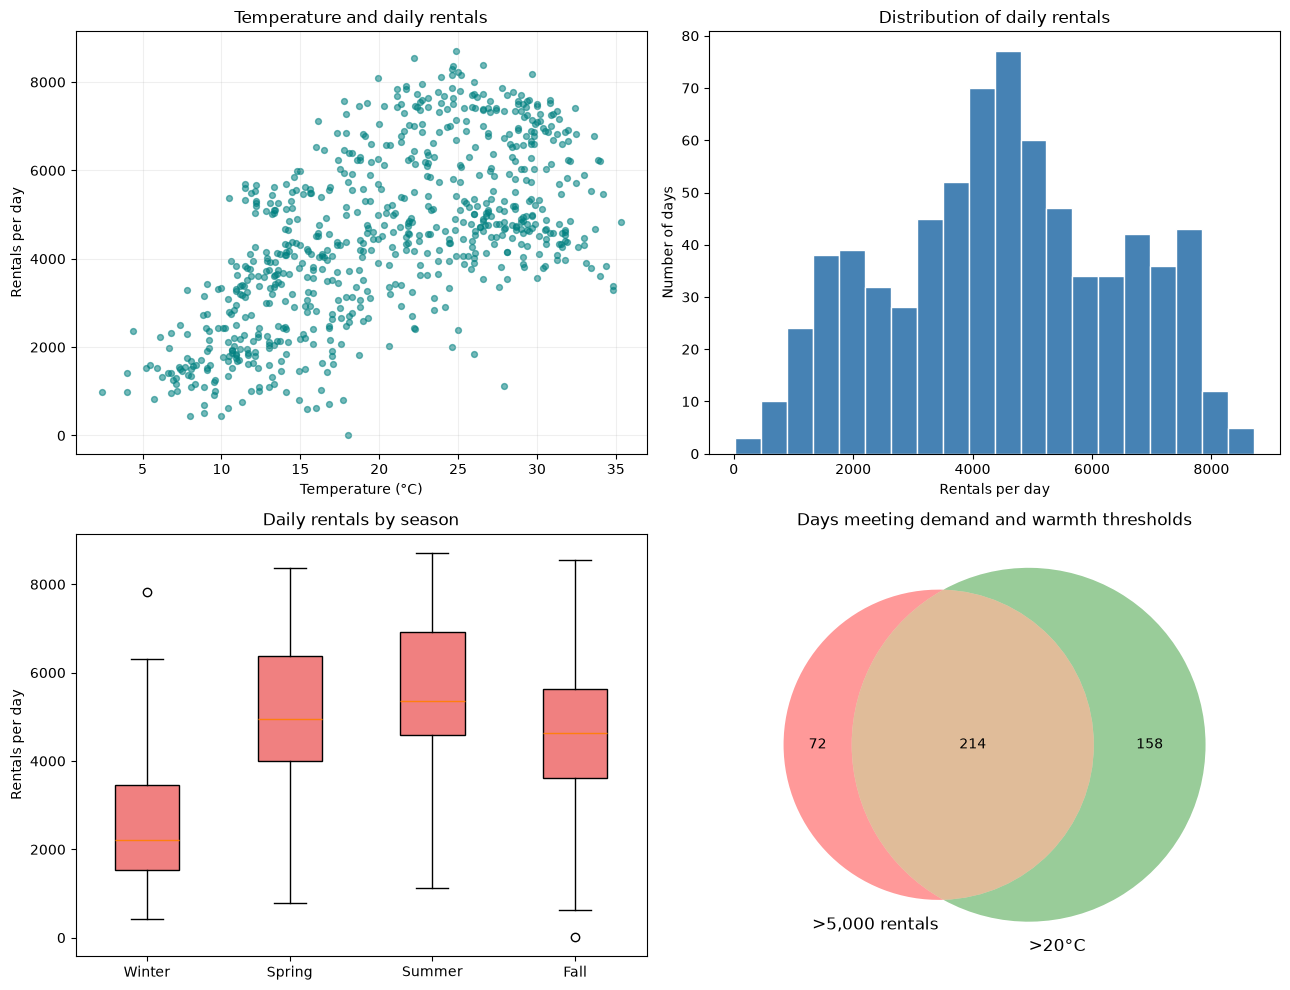

High-demand days: 286; warm days: 372; both: 214


In [ ]:
class BikeVisualizer:
    """Create four visualizations for the daily bike rental data."""

    # ============================================================
    # Step 1: Initialize the Visualizer
    # ============================================================

    def __init__(self, data):
        # Store the cleaned dataset so it can be used for plotting
        self.data = data


    # ============================================================
    # Step 2: Create All Four Required Visualizations
    # ============================================================

    def plot_all(self):
        """Create scatter plot, histogram, box plot, and Venn diagram."""

        # Create a 2 x 2 layout for the four visualizations
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))


        # ========================================================
        # Step 3: Scatter Plot - Temperature vs Daily Rentals
        # ========================================================

        # Compare temperature with the total number of daily rentals
        axes[0, 0].scatter(
            self.data.Temperature_C,
            self.data.Total_Rentals,
            alpha=0.55,
            s=18,
            color="teal"
        )

        # Add title and axis labels
        axes[0, 0].set(
            title="Temperature and daily rentals",
            xlabel="Temperature (°C)",
            ylabel="Rentals per day"
        )

        axes[0, 0].grid(alpha=0.2)


        # ========================================================
        # Step 4: Histogram - Distribution of Daily Rentals
        # ========================================================

        # Show how frequently different daily rental totals occur
        axes[0, 1].hist(
            self.data.Total_Rentals,
            bins=20,
            color="steelblue",
            edgecolor="white"
        )

        # Add title and axis labels
        axes[0, 1].set(
            title="Distribution of daily rentals",
            xlabel="Rentals per day",
            ylabel="Number of days"
        )


        # ========================================================
        # Step 5: Box Plot - Compare Rentals Across Seasons
        # ========================================================

        # Define the order of the seasons
        seasons = ["Winter", "Spring", "Summer", "Fall"]

        # Collect rental values separately for each season
        season_values = [
            self.data.loc[
                self.data.Season.eq(season),
                "Total_Rentals"
            ]
            for season in seasons
        ]

        # Create the seasonal box plot
        axes[1, 0].boxplot(
            season_values,
            patch_artist=True,
            boxprops={"facecolor": "lightcoral"}
        )

        # Add season names to the x-axis
        axes[1, 0].set_xticks(range(1, len(seasons) + 1))
        axes[1, 0].set_xticklabels(seasons)

        # Add title and axis label
        axes[1, 0].set(
            title="Daily rentals by season",
            ylabel="Rentals per day"
        )


        # ========================================================
        # Step 6: Venn Diagram - High Demand and Warm Days
        # ========================================================

        # Find days with more than 5,000 rentals
        high = set(
            self.data.index[
                self.data.Total_Rentals.gt(5000)
            ]
        )

        # Find days where temperature was above 20°C
        warm = set(
            self.data.index[
                self.data.Temperature_C.gt(20)
            ]
        )

        # Show the overlap between high-demand days and warm days
        venn2(
            [high, warm],
            set_labels=(">5,000 rentals", ">20°C"),
            ax=axes[1, 1]
        )

        axes[1, 1].set_title(
            "Days meeting demand and warmth thresholds"
        )


        # ========================================================
        # Step 7: Display the Visualizations
        # ========================================================

        # Adjust spacing so the plots do not overlap
        fig.tight_layout()

        # Display all four plots
        plt.show()


        # ========================================================
        # Step 8: Display Venn Diagram Counts
        # ========================================================

        # Print the number of high-demand days, warm days,
        # and days that meet both conditions
        print(
            f"High-demand days: {len(high)}; "
            f"warm days: {len(warm)}; "
            f"both: {len(high & warm)}"
        )


# ============================================================
# Step 9: Create the Visualizer Object and Display the Plots
# ============================================================

BikeVisualizer(df).plot_all()

## Presentation Guide

### 1. Introduction
Our project analyzes daily bike rental data to understand how temperature and season are related to the number of bike rentals.

### 2. Dataset and Data Cleaning
We use the UCI Bike Sharing Dataset, which contains 731 days of data from 2011 to 2012. Before analysis, we check for missing values, duplicates, valid season codes, and correct rental totals. We also convert temperature to Celsius and humidity to percentage.

### 3. Statistical Analysis
We calculate mean, median, mode, variance, standard deviation, and quartiles to understand the typical rental demand and how much the values vary.

### 4. Visualizations
We use four graphs:
- Scatter plot to compare temperature and rentals.
- Histogram to show the distribution of daily rentals.
- Box plot to compare rentals across seasons.
- Venn diagram to show the overlap between warm days and high-demand days.

### 5. Conclusion
The statistics and graphs help us understand historical patterns in bike rentals and how rental demand is associated with temperature and season.

## References

Fanaee-T, H. (2013). *Bike Sharing* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib_venn import venn2

# Ensure plots show directly in the notebook
%matplotlib inline

## Data cleansing

The source describes `day.csv` as daily rental and weather records with no missing values. Before analysis, we check for duplicate rows, translate the normalized temperature and humidity fields into easier-to-read units, rename key columns, and map the season codes to their documented labels. UCI defines season codes as 1 = Winter, 2 = Spring, 3 = Summer, and 4 = Fall. These steps improve readability and prevent the seasonal comparison from assigning days to the wrong seasons.

We keep the original fields as well as the converted fields so the raw values remain available for reference.

In [6]:
# Load real-world daily bike rental data
df = pd.read_csv('../data/day.csv')

print("Dataset successfully loaded.")


# ============================================================
# Data Validation
# ============================================================

# Step 1: Check that all required columns are available
required_columns = {
    'dteday',
    'season',
    'temp',
    'hum',
    'cnt',
    'casual',
    'registered'
}

missing_columns = required_columns - set(df.columns)

# Stop only if an important column itself is missing
if missing_columns:
    raise ValueError(f"Missing columns: {sorted(missing_columns)}")


# Step 2: Convert the date column to datetime format
df['dteday'] = pd.to_datetime(df['dteday'], errors='raise')


# Step 3: Check the dataset for missing values
# We only report them here because the UCI dataset is expected
# to contain no missing values.
missing_values = df.isna().sum().sum()

print(f"Number of rows: {len(df)}")
print(f"Missing values: {missing_values}")


# Step 4: Check for duplicate dates
duplicate_dates = df['dteday'].duplicated().sum()

print(f"Duplicate dates: {duplicate_dates}")


# Step 5: Validate season codes
# UCI defines: 1 = Winter, 2 = Spring, 3 = Summer, 4 = Fall
if not df['season'].isin([1, 2, 3, 4]).all():
    raise ValueError("Unexpected season code found.")


# Step 6: Verify that total rentals are correct
# Total rentals should equal casual rentals + registered rentals
if not (df['casual'] + df['registered'] == df['cnt']).all():
    raise ValueError("Rental totals do not match casual + registered rentals.")


# ============================================================
# Data Cleansing and Transformation
# ============================================================

# Step 7: Convert normalized temperature to Celsius
df['Temperature_C'] = (df['temp'] * 41).round(1)


# Step 8: Convert normalized humidity to percentage
df['Humidity_Pct'] = (df['hum'] * 100).round(1)


# Step 9: Rename important columns for readability
df.rename(columns={
    'cnt': 'Total_Rentals',
    'workingday': 'Working_Day',
    'season': 'Season_Code'
}, inplace=True)


# Step 10: Convert season codes to meaningful season names
season_map = {
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Fall'
}

df['Season'] = df['Season_Code'].map(season_map)


# Step 11: Remove duplicate rows if any exist
duplicates_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"Duplicate rows removed: {duplicates_before}")


# ============================================================
# Display Cleaned Data
# ============================================================

print("\nData successfully validated and cleansed:")

display(
    df[
        [
            'dteday',
            'Season',
            'Temperature_C',
            'Humidity_Pct',
            'Working_Day',
            'Total_Rentals'
        ]
    ].head(10)
)

Dataset successfully loaded.
Number of rows: 731
Missing values: 0
Duplicate dates: 0
Duplicate rows removed: 0

Data successfully validated and cleansed:


,dteday,Season,Temperature_C,Humidity_Pct,Working_Day,Total_Rentals
0,2011-01-01,Winter,14.1,80.6,0,985
1,2011-01-02,Winter,14.9,69.6,0,801
2,2011-01-03,Winter,8.1,43.7,1,1349
3,2011-01-04,Winter,8.2,59.0,1,1562
4,2011-01-05,Winter,9.3,43.7,1,1600
5,2011-01-06,Winter,8.4,51.8,1,1606
6,2011-01-07,Winter,8.1,49.9,1,1510
7,2011-01-08,Winter,6.8,53.6,0,959
8,2011-01-09,Winter,5.7,43.4,0,822
9,2011-01-10,Winter,6.2,48.3,1,1321


### Use Case Summary
This project examines how daily temperature and seasonal patterns relate to bike rental demand. City transportation managers can use these patterns to plan fleet availability, schedule maintenance during quieter periods, and reduce operating costs. The analysis supports informed planning by showing when riders may require more bicycles at stations.


## Object Oriented Analysis Class

In [5]:
class BikeDemandAnalyzer:
    """Class to perform statistical calculations and visualizations on bike sharing data."""
    
    def __init__(self, data):
        self.df = data

    def calculate_center_and_spread(self, column):
        """Calculates Mean, Median, Mode, Variance, Std Dev, and 4 Quartiles."""
        series = self.df[column]
        
        print(f"--- Summary Statistics for: {column} ---")
        display(f"Mean (Average):           {series.mean():.2f}")
        display(f"Median (Middle):          {series.median():.2f}")
        display(f"Mode (Most Frequent):     {series.mode()[0]:.2f}")
        display(f"Variance:                 {series.var():.2f}")
        display(f"Standard Deviation:       {series.std():.2f}")
        display(f"Quartile 1 (25%):         {series.quantile(0.25):.2f}")
        display(f"Quartile 2 (50%):         {series.quantile(0.50):.2f}")
        display(f"Quartile 3 (75%):         {series.quantile(0.75):.2f}")
        display(f"Quartile 4 (100%):        {series.quantile(1.00):.2f}")

    def display_numerical_summary(self):
        """Presents numerical summary table for core quantitative features."""
        print("--- NUMERICAL SUMMARY OF KEY VARIABLES ---")
        display(self.df[['Temperature_C', 'Humidity_Pct', 'Total_Rentals']].describe().round(2))

# Initialize and run statistical analysis
analyzer = BikeDemandAnalyzer(df)
print("\n")
analyzer.calculate_center_and_spread('Total_Rentals')
print("\n")
analyzer.calculate_center_and_spread('Temperature_C')
print("\n")
analyzer.display_numerical_summary()



--- Summary Statistics for: Total_Rentals ---


'Mean (Average):           4504.35'

'Median (Middle):          4548.00'

'Mode (Most Frequent):     1096.00'

'Variance:                 3752788.21'

...

'Quartile 2 (50%):         20.40'

'Quartile 3 (75%):         26.90'

'Quartile 4 (100%):        35.30'



--- NUMERICAL SUMMARY OF KEY VARIABLES ---


,Temperature_C,Humidity_Pct,Total_Rentals
count,731.00,731.00,731.00
mean,20.31,62.79,4504.35
std,7.51,14.24,1937.21
min,2.40,0.00,22.00
25%,13.80,52.00,3152.00
50%,20.40,62.70,4548.00
75%,26.90,73.00,5956.00
max,35.30,97.20,8714.00


## Visualizations

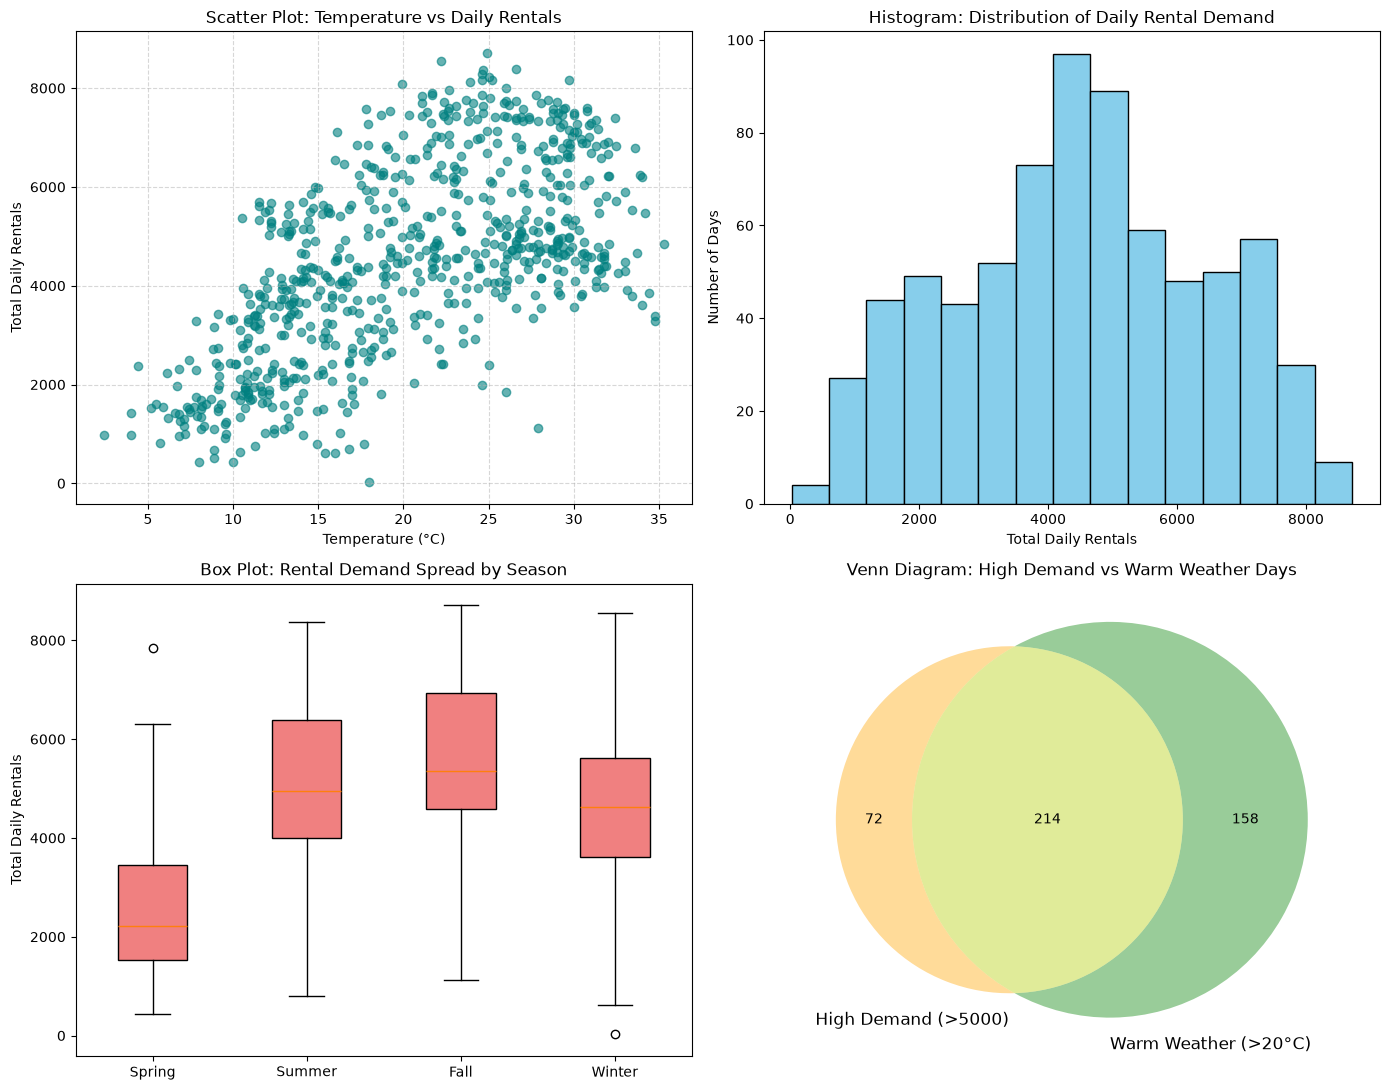

In [ ]:
class BikeVisualizer(BikeDemandAnalyzer):
    
    def plot_all_visualizations(self):
        """Generates Scatter plot, Histogram, Box plot, and Venn diagram."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 11))

        # 1. Scatter Plot (Temperature vs Daily Bike Rentals)
        axes[0, 0].scatter(self.df['Temperature_C'], self.df['Total_Rentals'], color='teal', alpha=0.6)
        axes[0, 0].set_title('Scatter Plot: Temperature vs Daily Rentals')
        axes[0, 0].set_xlabel('Temperature (°C)')
        axes[0, 0].set_ylabel('Total Daily Rentals')
        axes[0, 0].grid(True, linestyle='--', alpha=0.5)

        # 2. Histogram (Distribution of Daily Rentals)
        axes[0, 1].hist(self.df['Total_Rentals'], bins=15, color='skyblue', edgecolor='black')
        axes[0, 1].set_title('Histogram: Distribution of Daily Rental Demand')
        axes[0, 1].set_xlabel('Total Daily Rentals')
        axes[0, 1].set_ylabel('Number of Days')

        # 3. Box-Whisker Plot (Rental Spread across Seasons)
        seasons = ['Spring', 'Summer', 'Fall', 'Winter']
        season_data = [self.df[self.df['Season'] == s]['Total_Rentals'] for s in seasons]
        
        axes[1, 0].boxplot(season_data, tick_labels=seasons, patch_artist=True,
                           boxprops=dict(facecolor='lightcoral'))
        axes[1, 0].set_title('Box Plot: Rental Demand Spread by Season')
        axes[1, 0].set_ylabel('Total Daily Rentals')

        # 4. Venn Diagram (High-Demand Days vs Favorable Weather Days)
        # High Demand = days with more than 5,000 rentals
        # Warm Weather = days with temperature above 20°C
        high_demand = set(self.df[self.df['Total_Rentals'] > 5000].index)
        warm_weather = set(self.df[self.df['Temperature_C'] > 20].index)

        venn2([high_demand, warm_weather], 
              set_labels=('High Demand (>5000)', 'Warm Weather (>20°C)'), 
              ax=axes[1, 1],
              set_colors=('orange', 'green'))
        axes[1, 1].set_title('Venn Diagram: High Demand vs Warm Weather Days')

        plt.tight_layout()
        plt.show()

# Run visualizer
vis = BikeVisualizer(df)
vis.plot_all_visualizations()

### 1-Minute Presentation Script

Good day everyone! Today we are presenting our analysis of city bike-sharing demand across 731 days.

Our research question is: How do daily temperature and season relate to total bike rentals?

We first used descriptive statistics to understand typical rental demand and how much it varies across the dataset.

Our scatter plot shows that higher temperatures are generally associated with higher daily rental counts, although this relationship does not establish cause and effect.

Our box plot compares rental demand across the four seasons and shows differences in the distributions of daily rentals.

Finally, our Venn diagram compares days with more than 5,000 rentals with days above 20 degrees Celsius and shows how often these two conditions overlap.

Overall, these patterns can help transportation managers better understand bike rental demand and support operational planning.

